In [9]:
import numpy as np
import matplotlib.pyplot as plt

import vertical_profile as vp
import heterostructure_models.dot_2d as d2
import heterostructure_models.dot_3d as d3


No alloy disorder

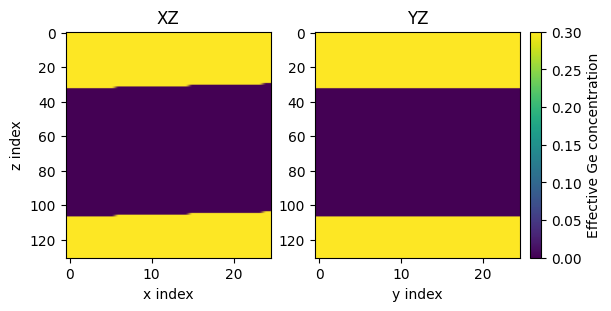

In [15]:
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

step_spacing = 9
d2stair = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='staircase', step_position=15, step_spacing=step_spacing, dx_unit_cells=1, nx=25)

d3model = d3.Dot3D(step_model=d2stair, dy_unit_cells=1)
lat3d = d3model.effective_lattice

lat_xz = lat3d[:, 0, :]
lat_yz = lat3d[0, :, :]

fig, ax = plt.subplots(1, 2, figsize=(6,3), layout='constrained')
ax[0].imshow(1-lat_xz.T, aspect='auto', cmap='viridis', vmin=0, vmax=0.3)
ax[0].set_title('XZ')
im2 = ax[1].imshow(1-lat_yz.T, aspect='auto', cmap='viridis', vmin=0, vmax=0.3)
plt.colorbar(im2, ax=ax[1], location='right', label='Effective Ge concentration')
ax[1].set_title('YZ')

ax[0].set_xlabel('x index')
ax[0].set_ylabel('z index')
ax[1].set_xlabel('y index')
plt.show()

Including alloy disorder

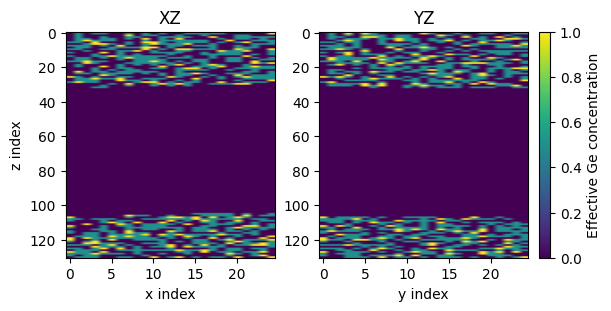

In [ ]:
# Since we chose dx_unit_cells and dy_unit_cells = 1, we should see Ge concentrations of 1, 0.5, or 1

lat3d_dis = d3model.generate_random_alloy_lattice()

lat_xz = lat3d_dis[:, 0, :]
lat_yz = lat3d_dis[0, :, :]

fig, ax = plt.subplots(1, 2, figsize=(6,3), layout='constrained')
ax[0].imshow(1-lat_xz.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax[0].set_title('XZ')
im2 = ax[1].imshow(1-lat_yz.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax[1], location='right', label='Effective Ge concentration')
ax[1].set_title('YZ')

ax[0].set_xlabel('x index')
ax[0].set_ylabel('z index')
ax[1].set_xlabel('y index')
plt.show()